In [10]:
import sys
import os
import pandas as pd

sys.path.append('../src/scripts')
sys.path.append('../src/classes')
from simulation import Simulation
from config import get_simulation_number
from data_scraping_in_results import scraper

In [11]:
mobility_file_path = '../src/sumo/csv/train_single.csv'
edge_file_path = '../src/inputs/train/edge_servers.json'
vehicle_file_path = '../src/inputs/train/vehicles_single.json'


In [12]:
_proposed="proposed"
_local= "local_only"
_offload = "offload_only"
_random = "random"
algorithms = [_proposed,_local,_offload,_random]
simulation_number = 69
report_paths = {}

for a in algorithms:
    report_paths[a] = ('../results/reports/'+str(simulation_number)+'_report_'+a+'_test.csv')
q_table_path = '../results/q_table/'+str(simulation_number)+'_q_table_proposed'

#overwrite specific report addresses for proposed
proposed_test_sim_number=69
proposed_test_number=2
report_paths[_proposed]='../results/reports/'+str(proposed_test_sim_number)+'_report_'+_proposed+'_test_'+str(proposed_test_number)+'.csv'


num_of_cars=20
end_time_limit=100000
# should_update_q_table = False
print(report_paths)

{'proposed': '../results/reports/69_report_proposed_test_2.csv', 'local_only': '../results/reports/69_report_local_only_test.csv', 'offload_only': '../results/reports/69_report_offload_only_test.csv', 'random': '../results/reports/69_report_random_test.csv'}


In [13]:
scrapers={}
for a in algorithms:
    scrapers[a] = scraper(report_paths[a],num_of_cars,end_time_limit)

---------------------------------------------
../results/reports/69_report_proposed_test_2.csv
The time limit is: 100000
Header --->
   vehicle_id  task_id  execution_location      size    distance  \
0           1        1                   0   7000000  193.826094   
1           1        3                   0  10000000  165.883824   
2           1        2                   1   5000000  184.436507   
3           1        4                   1   2000000  137.678077   
4           1        5                   1   3000000  112.105098   

   transfer_rate  execution_cycles  start_time  end_time  release_time  \
0   0.000000e+00        3000000000           1      3001             1   
1   0.000000e+00        2000000000        6001      8001          6001   
2   1.159480e+06        7000000000        8330      9730          3001   
3   3.669390e+06        7000000000        9730     11130          9001   
4   8.092026e+06        9000000000       13130     14930         12001   

   response_t

In [14]:
averages = {}
for a in algorithms:
    print("=========================================")
    print(a,"------->")
    averages[a] = scrapers[a].calc_average_all(False)

final_df = pd.concat(averages, names=['Algorithm'])
print(final_df)



proposed ------->
local_only ------->
offload_only ------->
random ------->
Algorithm                  
proposed      response_time     9216.681338
              total_energy         0.732783
local_only    response_time    27033.950617
              total_energy         0.590741
offload_only  response_time    14672.983673
              total_energy         1.199923
random        response_time     8381.750831
              total_energy         0.957664
dtype: float64


In [15]:
for a in algorithms:
    print("=========================================")
    print(a,"----------AVERAGED----->")
    scrapers[a].calc_average_for_each_car()

proposed ----------AVERAGED----->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1             3962.242424        1099.090909     1933.333333   
2             4918.781250        2424.718750     2131.250000   
3            11275.428571        1882.142857     2650.000000   
4             4157.666667         927.333333     2160.000000   
5             8442.655172        1842.172414     2475.862069   
6             6608.303030         418.393939     1775.757576   
7            12295.517241        3547.103448     2765.517241   
8            11103.913043        1309.913043     2565.217391   
9            12189.709677        3278.806452     2270.967742   
10            9052.230769         982.576923     2853.846154   
11            7903.333333        1901.900000     2106.666667   
12           11159.931034         761.724138     1896.551724   
13            9927.275862        3297.724138     2041.379310   
14    

In [16]:
for a in algorithms:
    print("=========================================")
    print(a,"----TOTAL------->")
    scrapers[a].calc_sum_for_each_car()

proposed ----TOTAL------->
            response_time  transmission_time  execution_time  \
vehicle_id                                                     
1                  130754              36270           63800   
2                  157401              77591           68200   
3                  315712              52700           74200   
4                  124730              27820           64800   
5                  244837              53423           71800   
6                  218074              13807           58600   
7                  356570             102866           80200   
8                  255390              30128           59000   
9                  377881             101643           70400   
10                 235358              25547           74200   
11                 237100              57057           63200   
12                 323638              22090           55000   
13                 287891              95634           59200   
14           

proposed -------AVERAGE----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1440             1439.0              639.0           800.0               0.0   
2001             2000.0                0.0          2000.0               0.2   
2085             2084.0               84.0          2000.0               0.0   
2735             2734.0             1734.0          1000.0               0.0   
2997             2996.0             1396.0          1600.0               0.0   
...                 ...                ...             ...               ...   
98811           17810.0             3458.0          2000.0               0.0   
99001            6000.0                0.0          4000.0               0.4   
99504           36503.0             3830.0          1000.0               0.0   
99961            6960.0             1485.0          1800.0               0.0   
99978     

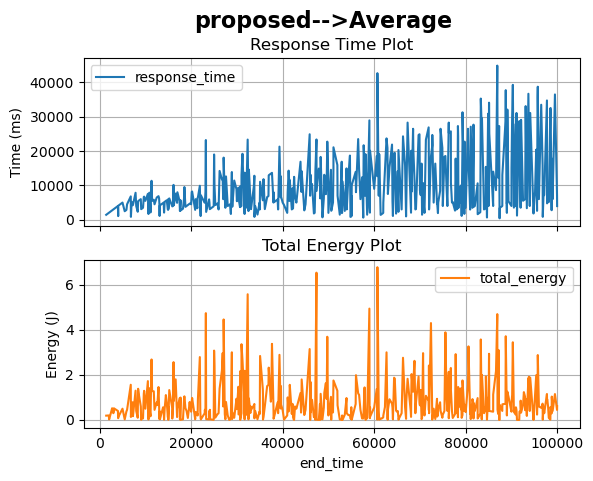

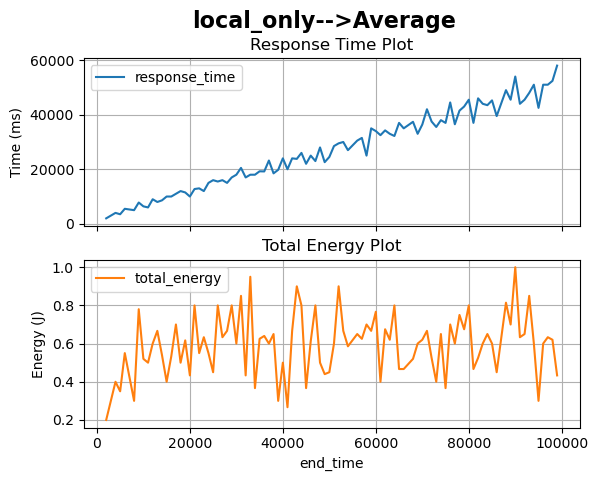

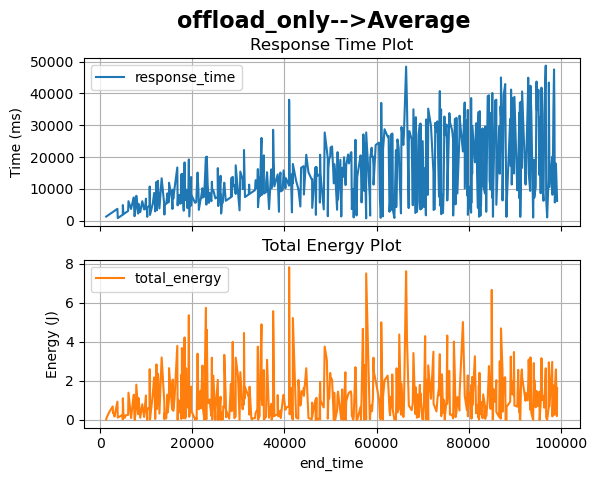

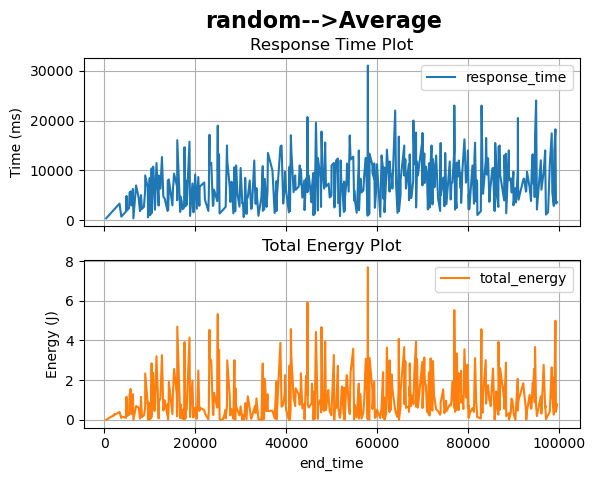

In [17]:
for a in algorithms:
    print("=========================================")
    print(a,"-------AVERAGE----->")
    scrapers[a].calc_average_for_each_end_time(plot=True,plot_title=a+"-->"+"Average")

proposed -------SUM----->
          response_time  transmission_time  execution_time  execution_energy  \
end_time                                                                       
1440               1439                639             800               0.0   
2001               4000                  0            4000               0.4   
2085               2084                 84            2000               0.0   
2735               2734               1734            1000               0.0   
2997               2996               1396            1600               0.0   
...                 ...                ...             ...               ...   
98811             17810               3458            2000               0.0   
99001             18000                  0           12000               1.2   
99504             36503               3830            1000               0.0   
99961              6960               1485            1800               0.0   
99978         

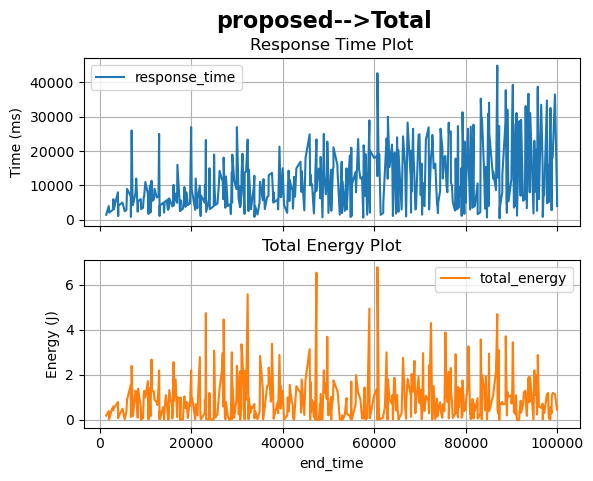

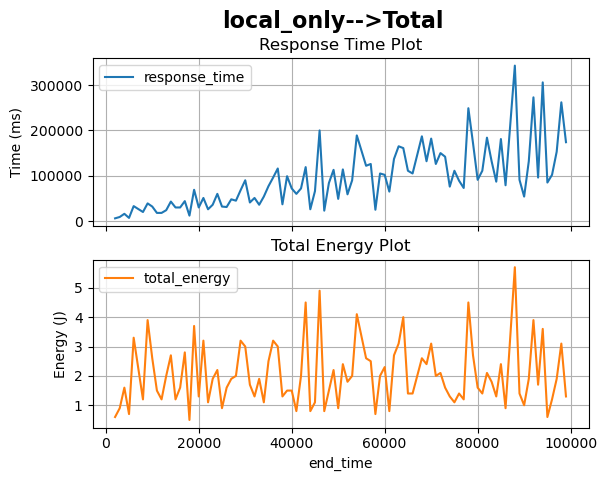

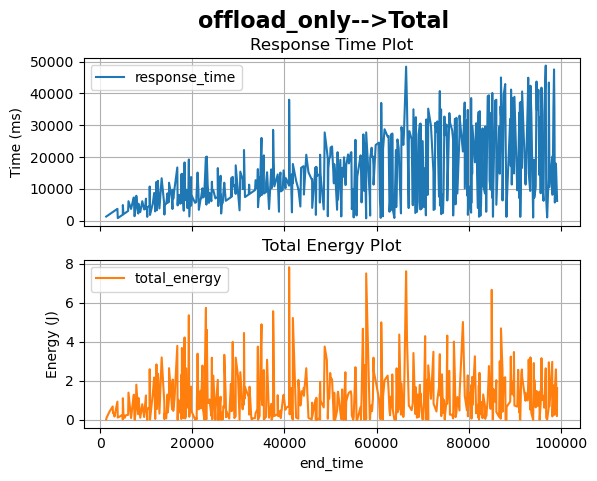

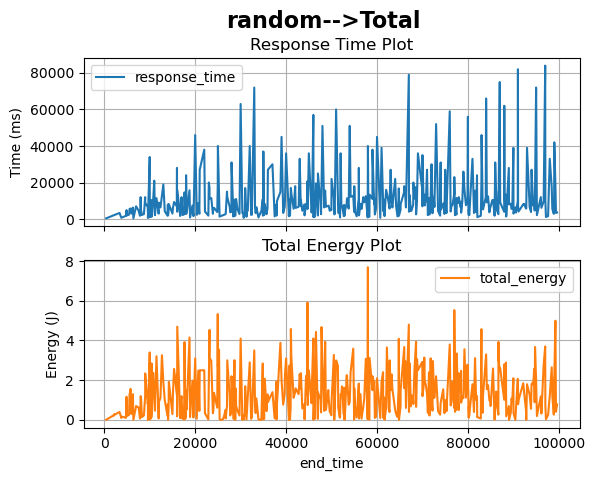

In [18]:
for a in algorithms:
    print("=========================================")
    print(a,"-------SUM----->")
    scrapers[a].calc_sum_for_each_end_time(plot=True,plot_title=a+"-->"+"Total")